In [1]:
## Standard Stuff
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.pyplot as plt
import dask.array as da
import numcodecs
import cftime

## HEALPix Specific
import healpix as hp
import easygems.healpix as egh
import easygems.remap as egr

import intake     # For catalogs
import zarr       # Data Formatting

In [2]:
zoom_select = 6

shield_cat = intake.open_catalog("/home/tmerlis/hackathon/xsh24_scream_main.yaml")["xsh24_coarse"]
shield = shield_cat(zoom=zoom_select).to_dask()
shield = shield.drop_vars("cell")
shield = shield.pipe(egh.attach_coords)

cru_cat = intake.open_catalog("/home/cs3554/CERES.yaml")["CERES_Cru23"]
ceres = cru_cat(zoom=zoom_select).to_dask()
ceres = ceres.pipe(egh.attach_coords)

shield

/home/cs3554/.conda/envs/easy25/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/home/cs3554/.conda/envs/easy25/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 249GB
Dimensions:  (time: 3560, cell: 49152, plev: 31, pfull: 79)
Coordinates:
  * pfull    (pfull) float32 316B 4.514 8.301 12.45 16.74 ... 989.5 994.3 998.3
  * plev     (plev) float32 124B 1.0 2.0 3.0 5.0 7.0 ... 925.0 950.0 975.0 1e+03
  * time     (time) object 28kB 2019-10-20 03:00:00 ... 2021-01-07 00:00:00
    crs      int64 8B 0
  * cell     (cell) int64 393kB 0 1 2 3 4 5 ... 49147 49148 49149 49150 49151
    lat      (cell) float64 393kB 0.5968 1.194 1.194 ... -1.194 -1.194 -0.5968
    lon      (cell) float64 393kB 45.0 45.7 44.3 45.0 ... 315.7 314.3 315.0
Data variables: (12/38)
    clivi    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    clt      (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    clwvi    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hflsd    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hfssd    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hur      (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>
    ...       ...
    uas      (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    va       (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>
    vas      (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    wa       (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>
    wap      (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>
    zg       (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>

In [8]:
# compute climatologies
shield_clim = shield.rsut.groupby("time.month").mean("time").load()
ceres_clim = ceres.F_TOA.groupby("time.month").mean("time").load()
shield_clim

<xarray.DataArray 'rsut' (month: 12, cell: 49152)> Size: 2MB
array([[ 66.00986 ,  70.38531 ,  70.00534 , ..., 139.23578 , 154.21068 ,
        138.30061 ],
       [ 79.43995 ,  83.379074,  76.67004 , ..., 220.2534  , 229.46188 ,
        229.01157 ],
       [ 55.057365,  55.972076,  66.27667 , ..., 180.98514 , 190.86156 ,
        184.64308 ],
       ...,
       [ 60.37582 ,  61.73216 ,  77.2076  , ...,  81.529495,  80.59832 ,
         76.58031 ],
       [ 75.82038 ,  79.90938 ,  89.72119 , ...,  75.49313 ,  82.6543  ,
         70.23992 ],
       [ 90.57037 ,  93.70518 ,  93.15743 , ..., 114.90004 , 129.23865 ,
        112.16181 ]], shape=(12, 49152), dtype=float32)
Coordinates:
    crs      int64 8B 0
  * cell     (cell) int64 393kB 0 1 2 3 4 5 ... 49147 49148 49149 49150 49151
    lat      (cell) float64 393kB 0.5968 1.194 1.194 ... -1.194 -1.194 -0.5968
    lon      (cell) float64 393kB 45.0 45.7 44.3 45.0 ... 315.7 314.3 315.0
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [9]:
def randomly_sample_half(ds):
    cells = ds.cell.values
    np.random.shuffle(cells)
    nhalf = len(cells) // 2
    cells1, cells2 = cells[:nhalf], cells[nhalf:]
    half1 = ds.sel(cell=cells1).mean("cell").values
    half2 = ds.sel(cell=cells2).mean("cell").values
    return half1, half2, half1-half2

randomly_sample_half(ceres_clim.mean("month"))

(array(98.91091, dtype=float32),
 array(98.94712, dtype=float32),
 np.float32(-0.036209106))

In [14]:
def n_samples(ds, n):
    asym = []
    for i in range(1,n):
        half1, half2, diff = randomly_sample_half(ds)
        asym.append(diff)
    return asym

n = 1000
ceres_asym = n_samples(ceres_clim.mean("month"), n)
shield_asym = n_samples(shield_clim.mean("month"), n)

In [15]:
eq_shield_asym = shield_clim.mean("month").where(shield_clim.lat > 0).mean("cell") - shield_clim.mean("month").where(shield_clim.lat < 0).mean("cell")
eq_ceres_asym = ceres_clim.mean("month").where(ceres_clim.lat > 0).mean("cell") - ceres_clim.mean("month").where(ceres_clim.lat < 0).mean("cell")

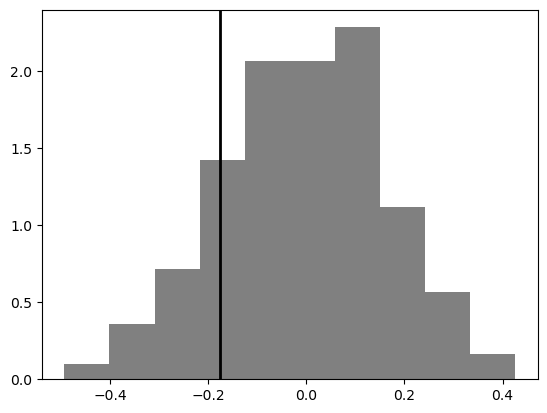

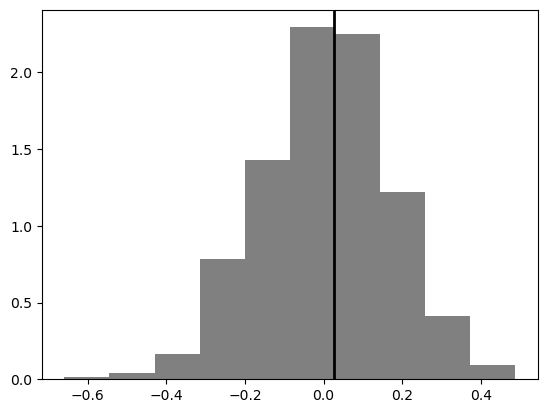

In [16]:
plt.hist(ceres_asym, color="grey", density=True)
plt.axvline(eq_ceres_asym, color="k", lw=2)
plt.show()

plt.hist(shield_asym, color="grey", density=True)
plt.axvline(eq_shield_asym, color="k", lw=2)
plt.show()

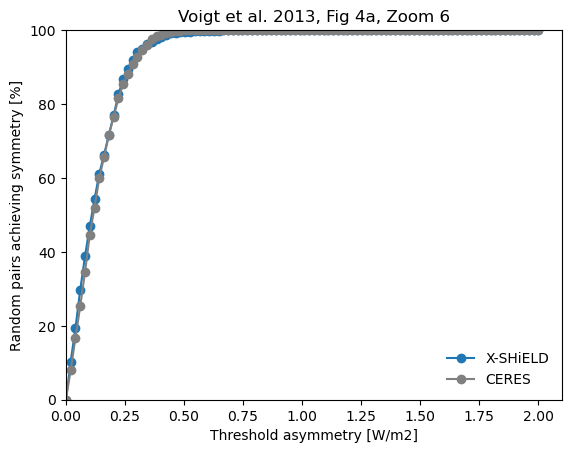

In [17]:
D = np.linspace(0,2,100)
P_ceres = np.zeros_like(D)
P_shield = np.zeros_like(D)
for i,Di in enumerate(D):
    P_ceres[i] = len(np.where(np.abs(ceres_asym) < Di)[0]) / n
    P_shield[i] = len(np.where(np.abs(shield_asym) < Di)[0]) / n

plt.plot(D,P_shield*100,"o-",color="C0", label="X-SHiELD")
# plt.axvline(np.abs(eq_shield_asym), color="C0", lw=2, alpha=0.5)

plt.plot(D,P_ceres*100,"o-",color="grey", label="CERES")
# plt.axvline(np.abs(eq_ceres_asym), color="grey", lw=2, alpha=0.5)

plt.xlim(0)
plt.xlabel("Threshold asymmetry [W/m2]")
plt.ylim(0,100)
plt.ylabel("Random pairs achieving symmetry [%]")
plt.legend(frameon=False, loc=4)
plt.title(f"Voigt et al. 2013, Fig 4a, Zoom {zoom_select}")
plt.savefig(f"Voigt_Fig4a_Zoom{zoom_select}.png",dpi=200,bbox_inches="tight",)
plt.show()